# GNN Training and Serving Pipeline Test

This notebook demonstrates how to execute the GNN training pipeline and serving inference code entirely within a local notebook environment, hitting your actual Google Spanner database for data without deploying to Vertex AI or storing artifacts in Google Cloud Storage.

It uses the exact same code blocks found in:
- `gnn/src/pipeline/run_pipeline_local.py`
- `gnn/src/train_hetgnn.py`
- `gnn/src/serve.py`

In [1]:
import os
import sys
import asyncio
import argparse
import datetime
from pathlib import Path
from unittest.mock import patch

# Ensure the gnn/src directory is in the Python path so we can import modules
src_path = str((Path.cwd().resolve().parent / "src").resolve())
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import train_hetgnn
import serve
import run_pipeline_local

## Configuration

Define the parameters for Spanner connectivity and the time windows for training and test data.

- **Training data**: `TRAIN_FROM` → `TRAIN_TO` — snapshots used to fit the model.
- **Test data**: `TEST_FROM` → `TEST_TO` — held-out snapshots used to evaluate inference.

In [2]:
# Credential auth: check for networkagent.json in ../src (local dev), fall back to ADC.
# Mirrors the approach used in gnn/src/utils/data.py (SpannerDataset.__init__).
_local_creds = str((Path.cwd().resolve().parent / "src" / "networkagent.json").resolve())
creds_path = os.getenv("GOOGLE_APPLICATION_CREDENTIALS", _local_creds)
if creds_path and os.path.exists(creds_path):
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = creds_path
    print(f"Using service-account credentials: {creds_path}")
else:
    print("networkagent.json not found — will use Application Default Credentials (ADC)")

project_id = os.getenv("GOOGLE_CLOUD_PROJECT", "agents-1234")
spanner_instance = os.getenv("SPANNER_INSTANCE", "networktopology-instance")
spanner_database = os.getenv("SPANNER_DATABASE", "networktopology-db")
interval_minutes = 0.5  # 30-second snapshot cadence

# ── Time windows ──────────────────────────────────────────────────────────────
# Training data: April 14 18:00 → 19:45
TRAIN_FROM = datetime.datetime(2026, 4, 14, 18,  0, 0)
TRAIN_TO   = datetime.datetime(2026, 4, 14, 19, 45, 0)

# Test / held-out data: April 14 19:45 → 20:00
TEST_FROM  = datetime.datetime(2026, 4, 14, 19, 45, 0)
TEST_TO    = datetime.datetime(2026, 4, 14, 20,  0, 0)

def _snapshots_in_window(t_from, t_to):
    """Number of snapshots that fit in the window at the current interval."""
    return int((t_to - t_from).total_seconds() / (interval_minutes * 60))

train_num = _snapshots_in_window(TRAIN_FROM, TRAIN_TO)
test_num  = _snapshots_in_window(TEST_FROM,  TEST_TO)

# ── Args namespaces (shared Spanner config + per-window time bounds) ──────────
def _base_args(**kwargs):
    base = dict(
        project=project_id,
        spanner_instance=spanner_instance,
        spanner_database=spanner_database,
        interval_minutes=interval_minutes,
        num_snapshots=None,  # overridden per window below
    )
    base.update(kwargs)
    return argparse.Namespace(**base)

train_args = _base_args(from_time=TRAIN_FROM, to_time=TRAIN_TO, num_snapshots=train_num)
test_args  = _base_args(from_time=TEST_FROM,  to_time=TEST_TO,  num_snapshots=test_num)

print(f"Interval        : {interval_minutes * 60:.0f}s")
print(f"Training window : {TRAIN_FROM.isoformat()} → {TRAIN_TO.isoformat()}  ({train_num} snapshots)")
print(f"Test window     : {TEST_FROM.isoformat()}  → {TEST_TO.isoformat()}   ({test_num} snapshots)")

output_dir = Path("notebook_artifacts")
output_dir.mkdir(exist_ok=True)
snapshots_dir      = output_dir / "snapshots"
test_snapshots_dir = output_dir / "test_snapshots"

Using service-account credentials: /Users/alvarossl/Documents/bt_gnn/gnnsandbox/gnn/src/networkagent.json
Interval        : 30s
Training window : 2026-04-14T18:00:00 → 2026-04-14T19:45:00  (210 snapshots)
Test window     : 2026-04-14T19:45:00  → 2026-04-14T20:00:00   (30 snapshots)


## 1. Ingest Data

Fetch network topology and metrics directly from your Spanner database using the SCD Type 2 logic inside `SpannerDataset`.

In [4]:
print("Fetching training data from Spanner...")
snapshots = run_pipeline_local.step_ingest(train_args, snapshots_dir)
print(f"Ingested {len(snapshots)} training snapshots.")

Fetching training data from Spanner...
2026-04-15 13:20:48,541 - local_pipeline - INFO - ============================================================
2026-04-15 13:20:48,542 - local_pipeline - INFO - STEP 1 — INGEST
2026-04-15 13:20:48,543 - local_pipeline - INFO - ============================================================
2026-04-15 13:20:48,544 - local_pipeline - INFO - Fetching 210 snapshots from networktopology-instance/networktopology-db (interval=0.5m)
2026-04-15 13:20:48,545 - utils.data - INFO - Initializing SpannerDataset: instance_id=networktopology-instance, database_id=networktopology-db, num_snapshots=210, interval_minutes=0.5, project_id=agents-1234, from_time=2026-04-14 18:00:00, to_time=2026-04-14 19:45:00
2026-04-15 13:20:48,726 - utils.data - INFO - SpannerDataset initialized successfully
2026-04-15 13:20:48,726 - utils.data - INFO - Generated 211 timestamps from 2026-04-14T18:00:00 to 2026-04-14T19:45:00
2026-04-15 13:20:48,727 - local_pipeline - INFO - Found 211 t

In [5]:
# ── Snapshot summary table ────────────────────────────────────────────────────
_hdr = (f"{'#':>3}  {'Timestamp':<26}  {'Routers':>9}  "
        f"{'Interfaces':>12}  {'BGPSessions':>13}  {'Edges':>6}")
print(f"\n{_hdr}")
print("-" * len(_hdr))
for _i, _s in enumerate(snapshots):
    _r   = [n for n in _s['nodes'] if n['type'] == 'router']
    _ifc = [n for n in _s['nodes'] if n['type'] == 'interface']
    _bgp = [n for n in _s['nodes'] if n['type'] == 'bgp_session']
    _r_up   = sum(1 for n in _r   if n.get('state') == 1.0)
    _i_up   = sum(1 for n in _ifc if n.get('state') == 1.0)
    _b_up   = sum(1 for n in _bgp if n.get('bgp_state') == 1.0)
    _ec = {}
    for _e in _s['edges']:
        _ec[_e['relation']] = _ec.get(_e['relation'], 0) + 1
    _etag = '  '.join(f"{k}={v}" for k, v in sorted(_ec.items()))
    print(
        f"{_i+1:>3}  {_s['timestamp']:<26}  "
        f"{_r_up}/{len(_r):<2} up  "
        f"{_i_up}/{len(_ifc):<4} up  "
        f"{_b_up}/{len(_bgp):<3} estab  "
        f"{len(_s['edges']):>6}  ({_etag})"
    )

# Show temporal features for last snapshot
if snapshots:
    _last = snapshots[-1]
    print("\n── Temporal features (last snapshot) ───────────────────────────")
    _ifc_nodes = [n for n in _last['nodes'] if n['type'] == 'interface']
    _bgp_nodes = [n for n in _last['nodes'] if n['type'] == 'bgp_session']
    _grads = sorted([abs(n.get('rx_err_gradient', 0.0)) for n in _ifc_nodes], reverse=True)
    print(f"  Interface rx_err_gradient   max={_grads[0] if _grads else 0:.6f}")
    _deltas = [n.get('prefix_count_delta', 0.0) for n in _bgp_nodes]
    print(f"  BGP prefix_count_delta      sessions with delta≠0: "
          f"{sum(1 for d in _deltas if d != 0)}/{len(_deltas)}")
    _uptimes = [n.get('session_uptime_norm', 0.0) for n in _bgp_nodes]
    print(f"  BGP session_uptime_norm     mean={sum(_uptimes)/len(_uptimes) if _uptimes else 0:.3f}")



  #  Timestamp                     Routers    Interfaces    BGPSessions   Edges
-------------------------------------------------------------------------------
  1  2026-04-14T18:00:00         14/14 up  52/66   up  0/0   estab     530  (connected_to=216  has_interface=66  interface_of=66  ospf_peer=182)
  2  2026-04-14T18:00:30         14/14 up  52/66   up  0/0   estab     530  (connected_to=216  has_interface=66  interface_of=66  ospf_peer=182)
  3  2026-04-14T18:01:00         14/14 up  52/66   up  0/0   estab     530  (connected_to=216  has_interface=66  interface_of=66  ospf_peer=182)
  4  2026-04-14T18:01:30         14/14 up  52/66   up  0/0   estab     530  (connected_to=216  has_interface=66  interface_of=66  ospf_peer=182)
  5  2026-04-14T18:02:00         14/14 up  52/66   up  0/0   estab     530  (connected_to=216  has_interface=66  interface_of=66  ospf_peer=182)
  6  2026-04-14T18:02:30         14/14 up  52/66   up  0/0   estab     530  (connected_to=216  has_interface=66  i

## 1b. Ingest Test Data

Fetch the **held-out test snapshots** for the period immediately after training (`TEST_FROM` → `TEST_TO`). These are saved separately and used later to evaluate model performance on unseen data.

In [6]:
print("Fetching test data from Spanner...")
test_snapshots = run_pipeline_local.step_ingest(test_args, test_snapshots_dir)
print(f"Ingested {len(test_snapshots)} test snapshots.")

Fetching test data from Spanner...
2026-04-15 13:22:35,150 - local_pipeline - INFO - ============================================================
2026-04-15 13:22:35,151 - local_pipeline - INFO - STEP 1 — INGEST
2026-04-15 13:22:35,151 - local_pipeline - INFO - ============================================================
2026-04-15 13:22:35,153 - local_pipeline - INFO - Fetching 30 snapshots from networktopology-instance/networktopology-db (interval=0.5m)
2026-04-15 13:22:35,154 - utils.data - INFO - Initializing SpannerDataset: instance_id=networktopology-instance, database_id=networktopology-db, num_snapshots=30, interval_minutes=0.5, project_id=agents-1234, from_time=2026-04-14 19:45:00, to_time=2026-04-14 20:00:00
2026-04-15 13:22:35,244 - utils.data - INFO - SpannerDataset initialized successfully
2026-04-15 13:22:35,245 - utils.data - INFO - Generated 31 timestamps from 2026-04-14T19:45:00 to 2026-04-14T20:00:00
2026-04-15 13:22:35,245 - local_pipeline - INFO - Found 31 timestamp

In [7]:
# ── Test snapshot summary ─────────────────────────────────────────────────────
_hdr = (f"{'#':>3}  {'Timestamp':<26}  {'Routers':>9}  "
        f"{'Interfaces':>12}  {'BGPSessions':>13}  {'Edges':>6}")
print(f"\n{_hdr}")
print("-" * len(_hdr))
for _i, _s in enumerate(test_snapshots):
    _r   = [n for n in _s['nodes'] if n['type'] == 'router']
    _ifc = [n for n in _s['nodes'] if n['type'] == 'interface']
    _bgp = [n for n in _s['nodes'] if n['type'] == 'bgp_session']
    _r_up   = sum(1 for n in _r   if n.get('state') == 1.0)
    _i_up   = sum(1 for n in _ifc if n.get('state') == 1.0)
    _b_up   = sum(1 for n in _bgp if n.get('bgp_state') == 1.0)
    _ec = {}
    for _e in _s['edges']:
        _ec[_e['relation']] = _ec.get(_e['relation'], 0) + 1
    _etag = '  '.join(f"{k}={v}" for k, v in sorted(_ec.items()))
    print(
        f"{_i+1:>3}  {_s['timestamp']:<26}  "
        f"{_r_up}/{len(_r):<2} up  "
        f"{_i_up}/{len(_ifc):<4} up  "
        f"{_b_up}/{len(_bgp):<3} estab  "
        f"{len(_s['edges']):>6}  ({_etag})"
    )


  #  Timestamp                     Routers    Interfaces    BGPSessions   Edges
-------------------------------------------------------------------------------
  1  2026-04-14T19:45:00         14/14 up  52/66   up  0/0   estab     530  (connected_to=216  has_interface=66  interface_of=66  ospf_peer=182)
  2  2026-04-14T19:45:30         14/14 up  52/66   up  0/0   estab     530  (connected_to=216  has_interface=66  interface_of=66  ospf_peer=182)
  3  2026-04-14T19:46:00         14/14 up  52/66   up  0/0   estab     530  (connected_to=216  has_interface=66  interface_of=66  ospf_peer=182)
  4  2026-04-14T19:46:30         14/14 up  52/66   up  0/0   estab     530  (connected_to=216  has_interface=66  interface_of=66  ospf_peer=182)
  5  2026-04-14T19:47:00         8/14 up  52/66   up  0/0   estab     530  (connected_to=216  has_interface=66  interface_of=66  ospf_peer=182)
  6  2026-04-14T19:47:30         11/14 up  52/66   up  0/0   estab     530  (connected_to=216  has_interface=66  in

## 2. Train HetGNN

Pass the fetched snapshots into the training script. This step:
1. Fits the `StandardScaler` on numerical features.
2. Converts data into PyTorch `HeteroData` graphs.
3. Trains the autoencoder over the specified number of epochs.
4. Saves `model.pth`, `scalers.pkl`, and `model_stats.pth` into our local `notebook_artifacts` folder.

In [3]:
import pickle, pathlib                                                                                                                                                             
                                         
snapshots = []                                                                                                                                                                     
for p in sorted(pathlib.Path("notebook_artifacts/snapshots").glob("*.pkl")):                                                                                                       
  with open(p, "rb") as f:                                                                                                                                                       
      snapshots.append(pickle.load(f))                                                                                                                                           
print(f"Loaded {len(snapshots)} snapshots from disk.")   

Loaded 211 snapshots from disk.


In [4]:
print("Training HetGNN on downloaded snapshots...")
model, val_loss, gb, history = train_hetgnn.train_hetgnn_on_snapshots(
    snapshot_objects=snapshots,
    output_dir=str(output_dir),
    hidden_channels=64,  # Matches production defaults
    num_layers=2,
    epochs_override=50   # Reduced for rapid feedback (default is 50)
)
print(f"Training completed. Validation Loss: {val_loss:.4f}")

Training HetGNN on downloaded snapshots...
2026-04-15 14:44:34,188 - train_hetgnn - INFO - Fitting scalers on all snapshots...
2026-04-15 14:44:34,209 - utils.gnn_utils - INFO - Fitted scaler for 'router' on 2954 node observations
2026-04-15 14:44:34,228 - utils.gnn_utils - INFO - Fitted scaler for 'interface' on 13926 node observations
2026-04-15 14:44:34,229 - utils.gnn_utils - WARNING - No data to fit scaler for node type 'bgp_session'
2026-04-15 14:44:34,231 - train_hetgnn - INFO - Scalers saved to notebook_artifacts/scalers.pkl
2026-04-15 14:44:34,232 - train_hetgnn - INFO - Processing snapshots into HeteroData...
2026-04-15 14:44:34,308 - train_hetgnn - INFO - Node types (3): ['router', 'interface', 'bgp_session']
2026-04-15 14:44:34,308 - train_hetgnn - INFO - Edge types (7): [('router', 'has_interface', 'interface'), ('router', 'ospf_peer', 'router'), ('router', 'bgp_peer', 'router'), ('router', 'hosts_session', 'bgp_session'), ('interface', 'interface_of', 'router'), ('interfa

## 2a. Training Loss Curve

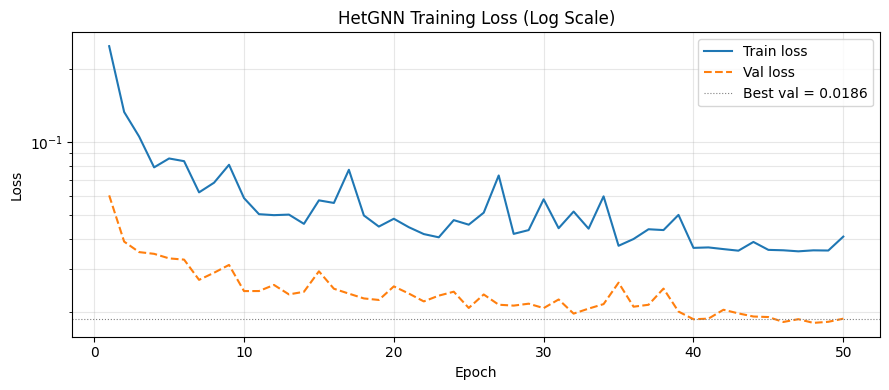

In [5]:
import matplotlib.pyplot as plt

epochs_ran = range(1, len(history["train"]) + 1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epochs_ran, history["train"], label="Train loss", linewidth=1.5)
ax.plot(epochs_ran, history["val"],   label="Val loss",   linewidth=1.5, linestyle="--")
ax.axhline(val_loss, color="grey", linewidth=0.8, linestyle=":", label=f"Best val = {val_loss:.4f}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_yscale("log")
ax.set_title("HetGNN Loss (Log Scale)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## 2b. Test-set Evaluation

In [6]:
import pickle, pathlib                                                                                                                                                             
                                                                                                                                                                                     
test_snapshots = []                                                                                                                                                                
for p in sorted(pathlib.Path("notebook_artifacts/test_snapshots").glob("*.pkl")):                                                                                                  
  with open(p, "rb") as f:                                                                                                                                                       
      test_snapshots.append(pickle.load(f))                                                                                                                                      
print(f"Loaded {len(test_snapshots)} test snapshots from disk.")   

Loaded 31 test snapshots from disk.


── Test-set MSE per node type ───────────────────────────────────────
  Node type             n    mean MSE     max MSE   threshold   anomalies
  --------------------------------------------------------------------
  router              434      0.1431      3.5383        0.15         66 (15.2%)
  interface          2046      0.0028      0.1022        0.20          0 (0.0%)


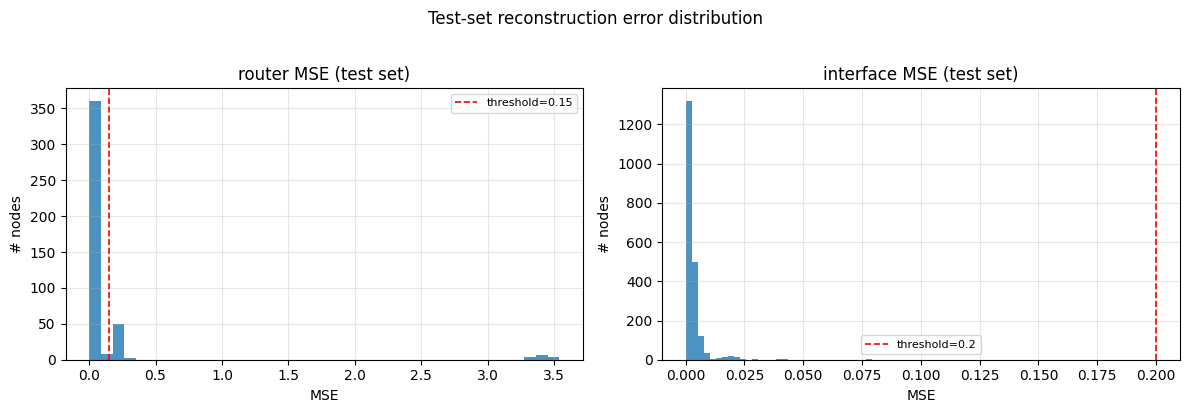

In [7]:
import torch
import statistics
from utils.gnn_utils import ANOMALY_THRESHOLDS, ROUTER_FEATURES, INTERFACE_FEATURES

model.eval()
criterion = torch.nn.MSELoss(reduction="none")

# Process test snapshots through the trained GraphBuilder
test_hetero = [gb.process_snapshot(s) for s in test_snapshots]

per_type_mse = {"router": [], "interface": [], "bgp_session": []}

with torch.no_grad():
    for hdata in test_hetero:
        recon_dict, _ = model(hdata.x_dict, hdata.edge_index_dict)
        for ntype, recon in recon_dict.items():
            if ntype not in hdata.x_dict:
                continue
            node_mse = criterion(recon, hdata[ntype].x).mean(dim=1)
            per_type_mse[ntype].extend(node_mse.tolist())

print("── Test-set MSE per node type ───────────────────────────────────────")
print(f"  {'Node type':<16} {'n':>6}  {'mean MSE':>10}  {'max MSE':>10}  {'threshold':>10}  {'anomalies':>10}")
print("  " + "-"*68)
for ntype, scores in per_type_mse.items():
    if not scores:
        continue
    thresh = ANOMALY_THRESHOLDS.get(ntype, 0.20)
    n_anom = sum(1 for s in scores if s > thresh)
    print(f"  {ntype:<16} {len(scores):>6}  {statistics.mean(scores):>10.4f}  "
          f"{max(scores):>10.4f}  {thresh:>10.2f}  {n_anom:>9} ({100*n_anom/len(scores):.1f}%)")

# Per-type MSE distribution plot
fig, axes = plt.subplots(1, len([k for k, v in per_type_mse.items() if v]),
                         figsize=(12, 4), sharey=False)
if not hasattr(axes, "__iter__"):
    axes = [axes]
ax_iter = iter(axes)
for ntype, scores in per_type_mse.items():
    if not scores:
        continue
    ax = next(ax_iter)
    ax.hist(scores, bins=40, edgecolor="none", alpha=0.8)
    thresh = ANOMALY_THRESHOLDS.get(ntype, 0.20)
    ax.axvline(thresh, color="red", linewidth=1.2, linestyle="--", label=f"threshold={thresh}")
    ax.set_title(f"{ntype} MSE (test set)")
    ax.set_xlabel("MSE")
    ax.set_ylabel("# nodes")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle("Test-set reconstruction error distribution", y=1.02)
plt.tight_layout()
plt.show()

## 3. Serve (Inference)

Test the production serving code.
In production, `serve.py` queries Google Cloud Storage to find the latest trained model (via `latest_run.json`). To test it locally, we temporarily patch those loader functions to point to the artifacts we just trained in our `notebook_artifacts` directory.

This execution will:
1. Reload the model and scalers we just saved.
2. Fetch one *new* real snapshot from Spanner.
3. Perform a forward pass through the model to compute node embeddings and MSE reconstruction error.
4. **Write the results** directly back to the Spanner `NodeEmbedding` table.
5. Print the anomaly scores.

In [15]:
print("Setting up serving components with local artifacts instead of GCS...")

def mock_load_manifest():
    return {"run_id": "notebook_test_run"}

def mock_download_artefacts(manifest):
    return output_dir

async def test_serving():
    # We use unittest.mock.patch so serve.py doesn't try to download from GCS
    with patch("serve._load_manifest", side_effect=mock_load_manifest), \
         patch("serve._download_artefacts", side_effect=mock_download_artefacts), \
         patch("serve.SPANNER_INSTANCE", spanner_instance), \
         patch("serve.SPANNER_DATABASE", spanner_database), \
         patch("serve.GOOGLE_CLOUD_PROJECT", project_id):

        # Run the actual inference code
        results = await serve._run_inference()

        print("\n─── INFERENCE RESULTS ─────────────────────────────────────────")
        print(f"Snapshot timestamp : {results['snapshot_timestamp']}")
        print(f"Total anomalies    : {results['anomaly_count']}")

        # Per-type anomaly summary with per-type threshold
        thresholds = serve._cache.get("thresholds", serve._FALLBACK_THRESHOLDS)
        print("\n  Node Type        Nodes   Anomalies   Threshold")
        print("  " + "-"*52)
        for ntype, scores in results['anomaly_scores'].items():
            thresh = thresholds.get(ntype, 0.20)
            n_anom = sum(1 for s in scores if s > thresh)
            print(f"  {ntype:<18} {len(scores):>5}   {n_anom:>9}   MSE>{thresh:.2f}")

        # ── RCA decision tree for anomalous routers ──────────────────────────
        print("\n── RCA Decision Tree ───────────────────────────────────────────")
        r_scores  = results['anomaly_scores'].get('router', [])
        r_expls   = results.get('anomaly_explanations', {}).get('router', [])
        bgp_scores = results['anomaly_scores'].get('bgp_session', [])
        bgp_expls  = results.get('anomaly_explanations', {}).get('bgp_session', [])
        r_thresh  = thresholds.get('router', 0.15)
        b_thresh  = thresholds.get('bgp_session', 0.10)

        anom_routers = [(i, s) for i, s in enumerate(r_scores) if s > r_thresh]
        if not anom_routers:
            print("  No anomalous routers detected — network looks healthy.")
        else:
            for idx, score in anom_routers[:5]:   # Show first 5
                expl = r_expls[idx] if idx < len(r_expls) else {}
                top_f = expl.get('top_features', [])
                feat_str = ', '.join(f'{f["feature"]}' for f in top_f) if top_f else 'n/a'
                print(f"  ▶ Router[{idx}] MSE={score:.4f}  top features: {feat_str}")

                # Check if any BGP sessions on this router are also anomalous
                anom_bgp = [i for i, s in enumerate(bgp_scores) if s > b_thresh]
                if anom_bgp:
                    print(f"    ↳ {len(anom_bgp)} BGP session(s) also anomalous — possible RR failure")
                    for bi in anom_bgp[:3]:
                        b_expl = bgp_expls[bi] if bi < len(bgp_expls) else {}
                        b_top  = b_expl.get('top_features', [])
                        b_str  = ', '.join(f'{f["feature"]}' for f in b_top) if b_top else 'n/a'
                        print(f"       BGPSession[{bi}] MSE={bgp_scores[bi]:.4f}  top: {b_str}")
                else:
                    print(f"    ↳ BGP sessions healthy — likely interface or CPU issue")

# Await the async server inference method
await test_serving()


Setting up serving components with local artifacts instead of GCS...
2026-04-14 10:23:23,206 - gnn.serve - INFO - Loading model for run_id=notebook_test_run...
2026-04-14 10:23:23,209 - utils.data - INFO - Initializing SpannerDataset: instance_id=networktopology-instance, database_id=networktopology-db, num_snapshots=1, interval_minutes=5, project_id=agents-1234
2026-04-14 10:23:23,277 - utils.data - INFO - SpannerDataset initialized successfully
2026-04-14 10:23:23,728 - utils.data - INFO - Generated 1 timestamps from 2026-04-14T09:23:17.747231 to 2026-04-14T09:23:17.747231
2026-04-14 10:23:23,730 - utils.data - INFO - Fetching snapshot for timestamp: 2026-04-14T09:23:17.747231
2026-04-14 10:23:23,764 - utils.data - INFO - Fetched 14 routers
2026-04-14 10:23:23,787 - utils.data - INFO - Fetched 66 interfaces
2026-04-14 10:23:23,889 - utils.data - INFO - Fetched 0 BGP sessions
2026-04-14 10:23:23,928 - utils.data - INFO - Snapshot 2026-04-14T09:23:17.747231: 80 nodes, 464 edges
2026-04

/Users/alvarossl/Documents/bt_gnn/gnnsandbox/gnn/src/model/hetgnn.py:27: UserWarning: There exist node types ({'bgp_session'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  self.convs.append(HeteroConv(conv_dict, aggr='sum'))


2026-04-14 10:23:24,395 - utils.data - INFO - Generated 1 timestamps from 2026-04-14T09:23:17.747231 to 2026-04-14T09:23:17.747231
2026-04-14 10:23:24,396 - utils.data - INFO - Fetching snapshot for timestamp: 2026-04-14T09:23:17.747231
2026-04-14 10:23:24,422 - utils.data - INFO - Fetched 14 routers
2026-04-14 10:23:24,455 - utils.data - INFO - Fetched 66 interfaces
2026-04-14 10:23:24,559 - utils.data - INFO - Fetched 0 BGP sessions
2026-04-14 10:23:24,598 - utils.data - INFO - Snapshot 2026-04-14T09:23:17.747231: 80 nodes, 464 edges
2026-04-14 10:23:24,599 - gnn.serve - INFO - Fetched snapshot at 2026-04-14T09:23:17.747231
2026-04-14 10:23:24,614 - gnn.serve - INFO -   router: 14 nodes, 0 anomalies (MSE > 0.15)
2026-04-14 10:23:24,616 - gnn.serve - INFO -   interface: 66 nodes, 0 anomalies (MSE > 0.2)
2026-04-14 10:23:24,710 - gnn.serve - INFO - Wrote 80 NodeEmbedding rows to Spanner
2026-04-14 10:23:24,711 - gnn.serve - INFO - Inference complete — 0 anomalies detected.

─── INFEREN

## 4. Synthetic Anomaly Inference and Diagnosis

In this section, we load the synthetic snapshots generated by `generate_anomalies.py`, which contains a CRC error spike and a CPU spike. We then run inference and visualize how the GNN flags these specific nodes.

In [9]:
import json
import torch
import networkx as nx
import matplotlib.pyplot as plt
from utils.gnn_utils import GraphBuilder, NODE_TYPES, INTERFACE_FEATURES, ROUTER_FEATURES

def load_synthetic_snapshots(data_dir):
    snapshots = []
    for p in sorted(data_dir.glob("*.json")):
        with open(p, "r") as f:
            snapshots.append(json.load(f))
    return snapshots

async def test_synthetic_inference():
    print(f"Loading synthetic snapshots from {synthetic_dir}...")
    synthetic_snapshots = load_synthetic_snapshots(synthetic_dir)
    if not synthetic_snapshots:
        print("No synthetic snapshots found! Run 'python3 generate_anomalies.py' first.")
        return

    # Use the latest snapshot (the one with injected anomalies)
    latest_snap = synthetic_snapshots[-1]
    print(f"Running inference on snapshot: {latest_snap['timestamp']}")

    # 1. Setup Model and GraphBuilder
    manifest = mock_load_manifest()
    _ensure_model_loaded(manifest)
    model = _cache["model"]
    graph_builder = _cache["graph_builder"]
    device = _cache["device"]
    thresholds = _cache.get("thresholds", _FALLBACK_THRESHOLDS)

    # 2. Process into HeteroData
    hetero_data = graph_builder.process_snapshot(latest_snap)
    node_id_map = hetero_data.node_id_map
    hetero_data = hetero_data.to(device)

    # 3. Inference
    with torch.no_grad():
        recon_dict, _ = model(hetero_data.x_dict, hetero_data.edge_index_dict)

    # 4. Diagnose Anomalies
    print("\n─── SYNTHETIC INFERENCE RESULTS ────────────────────────────────")
    
    found_anomalies = []
    
    for ntype, recon in recon_dict.items():
        if ntype not in hetero_data.x_dict:
            continue
        orig = hetero_data[ntype].x
        feat_mse = ((recon - orig) ** 2)
        node_mse = feat_mse.mean(dim=1)
        threshold = thresholds.get(ntype, 0.20)
        
        feat_names = ROUTER_FEATURES if ntype == 'router' else INTERFACE_FEATURES if ntype == 'interface' else []
        
        for idx in range(node_mse.size(0)):
            score = node_mse[idx].item()
            if score > threshold:
                node_id = node_id_map[ntype][idx]
                top_feat_idx = torch.argmax(feat_mse[idx]).item()
                top_feat_name = feat_names[top_feat_idx] if top_feat_idx < len(feat_names) else "unknown"
                
                found_anomalies.append({
                    'id': node_id, 'type': ntype, 'score': score, 
                    'top_feature': top_feat_name, 'threshold': threshold
                })
                print(f"[!] ANOMALY: {ntype:<10} ID: {node_id:<30} MSE: {score:.4f} (>{threshold}) Top: {top_feat_name}")

    # 5. Visualize the "Infected" Graph
    G = nx.Graph()
    node_colors = []
    labels = {}
    
    # Add nodes and color by anomaly status
    anom_ids = {a['id'] for a in found_anomalies}
    
    for node in latest_snap['nodes']:
        if node['type'] in ['router', 'interface']:
            G.add_node(node['id'])
            labels[node['id']] = node.get('hostname', node.get('name'))
            if node['id'] in anom_ids:
                node_colors.append('red')
            else:
                node_colors.append('lightgreen' if node['type'] == 'router' else 'lightblue')

    # Add edges
    for edge in latest_snap['edges']:
        if edge['source'] in G and edge['target'] in G:
            G.add_edge(edge['source'], edge['target'])

    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, k=0.3)
    nx.draw(G, pos, labels=labels, with_labels=True, node_color=node_colors, node_size=800, font_size=7)
    plt.title(f"Synthetic Anomaly Detection Map\n(Red = Detected Anomaly at {latest_snap['timestamp']})")
    plt.show()

await test_synthetic_inference()

NameError: name 'synthetic_dir' is not defined